In [7]:
test_folder = './test'
model_path = './net_full_model.pt'

In [8]:
class_names = ['boston_bull', 'dingo', 'pekinese', 'bluetick', 'golden_retriever', 'bedlington_terrier', 'borzoi', 'basenji', 'scottish_deerhound', 'shetland_sheepdog', 'walker_hound', 'maltese_dog', 'norfolk_terrier', 'african_hunting_dog', 'wire-haired_fox_terrier', 'redbone', 'lakeland_terrier', 'boxer', 'doberman', 'otterhound', 'standard_schnauzer', 'irish_water_spaniel', 'black-and-tan_coonhound', 'cairn', 'affenpinscher', 'labrador_retriever', 'ibizan_hound', 'english_setter', 'weimaraner', 'giant_schnauzer', 'groenendael', 'dhole', 'toy_poodle', 'border_terrier', 'tibetan_terrier', 'norwegian_elkhound', 'shih-tzu', 'irish_terrier', 'kuvasz', 'german_shepherd', 'greater_swiss_mountain_dog', 'basset', 'australian_terrier', 'schipperke', 'rhodesian_ridgeback', 'irish_setter', 'appenzeller', 'bloodhound', 'samoyed', 'miniature_schnauzer', 'brittany_spaniel', 'kelpie', 'papillon', 'border_collie', 'entlebucher', 'collie', 'malamute', 'welsh_springer_spaniel', 'chihuahua', 'saluki', 'pug', 'malinois', 'komondor', 'airedale', 'leonberg', 'mexican_hairless', 'bull_mastiff', 'bernese_mountain_dog', 'american_staffordshire_terrier', 'lhasa', 'cardigan', 'italian_greyhound', 'clumber', 'scotch_terrier', 'afghan_hound', 'old_english_sheepdog', 'saint_bernard', 'miniature_pinscher', 'eskimo_dog', 'irish_wolfhound', 'brabancon_griffon', 'toy_terrier', 'chow', 'flat-coated_retriever', 'norwich_terrier', 'soft-coated_wheaten_terrier', 'staffordshire_bullterrier', 'english_foxhound', 'gordon_setter', 'siberian_husky', 'newfoundland', 'briard', 'chesapeake_bay_retriever', 'dandie_dinmont', 'great_pyrenees', 'beagle', 'vizsla', 'west_highland_white_terrier', 'kerry_blue_terrier', 'whippet', 'sealyham_terrier', 'standard_poodle', 'keeshond', 'japanese_spaniel', 'miniature_poodle', 'pomeranian', 'curly-coated_retriever', 'yorkshire_terrier', 'pembroke', 'great_dane', 'blenheim_spaniel', 'silky_terrier', 'sussex_spaniel', 'german_short-haired_pointer', 'french_bulldog', 'bouvier_des_flandres', 'tibetan_mastiff', 'english_springer', 'cocker_spaniel', 'rottweiler']

In [9]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [10]:
import torch.nn as nn
from torchvision import models

class PretrainViT(nn.Module):

  def __init__(self):
    super(PretrainViT, self).__init__()
    model = models.vit_l_16(pretrained=True)
    num_classifier_feature = model.heads.head.in_features
    model.heads.head = nn.Sequential(
      nn.Linear(num_classifier_feature, 120)
    )
    self.model = model

    for param in self.model.named_parameters():
      if "heads" not in param[0]:
        param[1].requires_grad = False

  def forward(self, x):
    return self.model(x)

model = torch.load(model_path, map_location=device, weights_only=False)
_ = model.eval()

In [11]:
import torchvision.transforms as transforms
from PIL import Image

transform = transforms.Compose([
  transforms.Resize((224, 224)),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def preprocess_image(image_path):
  image = Image.open(image_path).convert("RGB")
  image = transform(image).unsqueeze(0)
  return image

def predict(image_path):
  image = preprocess_image(image_path)
  with torch.no_grad():
    output = model(image)
    # print(output)
    predicted = torch.argmax(output)
    # print(predicted)
  return class_names[predicted]

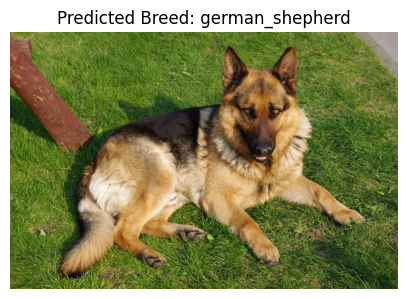

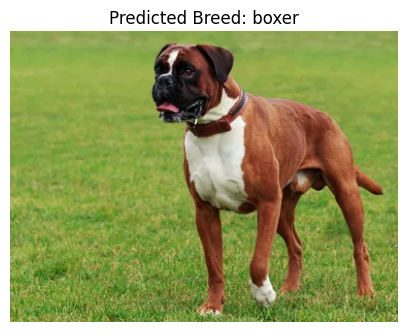

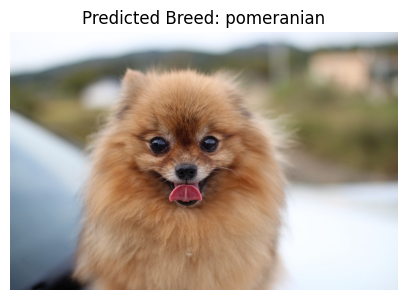

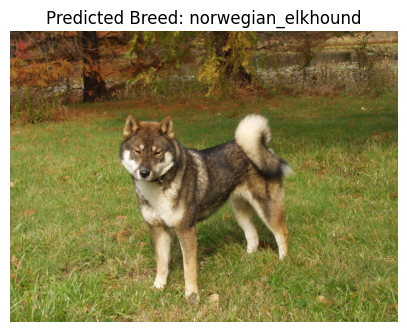

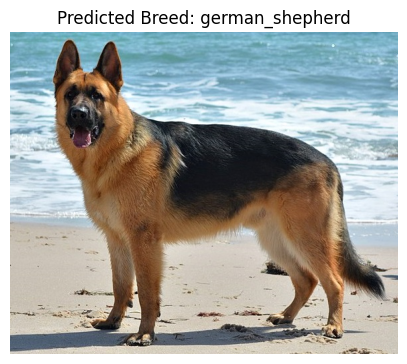

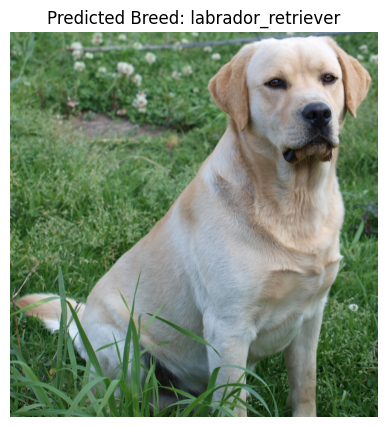

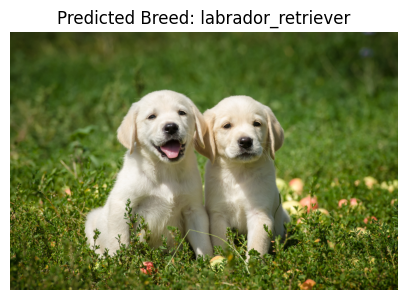

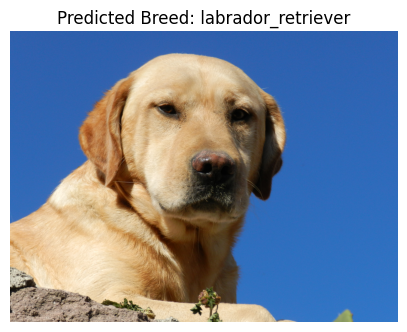

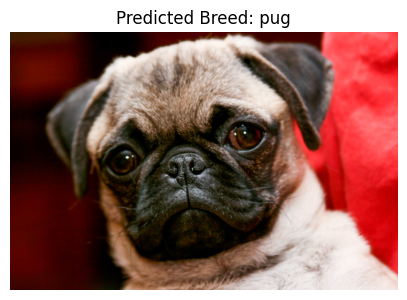

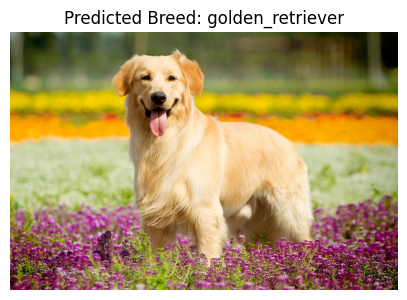

In [12]:
import os
import matplotlib.pyplot as plt

for img_name in os.listdir(test_folder):
  img_path = os.path.join(test_folder, img_name)
  predicted_breed = predict(img_path)

  img = plt.imread(img_path)
  plt.figure(figsize=(5, 5))
  plt.imshow(img)
  plt.title(f"Predicted Breed: {predicted_breed}")
  plt.axis("off")
  plt.show()